In [86]:
import numpy as np
import pandas as pd
from matplotlib.lines import lineStyles
from plotly.io import show
from matplotlib import pyplot as plt
import seaborn as sns
from tabulate import tabulate
import vectorbt as vbt
import math

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Utils import *
from ggTrader.Signals import *

In [87]:
top_kraken = [
    "BTC",  # 1 Bitcoin
    "ETH",  # 2 Ethereum
    "XRP",  # 3 XRP
    # "BNB",  # 4 BNB
    "SOL",  # 5 Solana
    "TRX",  # 6 TRON
    "DOGE",  # 7 Dogecoin
    "ADA",  # 8 Cardano
    # "HYPE",  # 9 Hyperliquid
    "LINK",  # 10 Chainlink
    "BCH",  # 11 Bitcoin Cash
    "XLM",  # 12 Stellar
    "SUI",  # 13 Sui
    # "HBAR",  # 14 Hedera
    "AVAX",  # 15 Avalanche
    "ZEC",  # 16 Zcash
    "LTC",  # 17 Litecoin
    "XMR",  # 18 Monero
    "SHIB",  # 19 Shiba Inu
    # "TON",  # 20 Toncoin
    # "CRO",  # 21 Crypto.com
    "DOT",  # 22 Polkadot
    # "MNT",  # 23 Mantle
    # "TAO",  # 24 Bittensor
    "UNI",  # 25 Uniswap
]

Setup

notes: https://greyhoundanalytics.com/blog/plotting-custom-graphs-in-vectorbt/

In [88]:
# setup
k = KrakenHistoricalData()

start_equity = 1000
symbols = ["BTC"]
# symbols = top_kraken[:4]
interval = "4h"
n_trials = 100
min_trades = 20
low_trades = False
max_lookback = int(6 * 3)  # i want to look back no further than 3 days
sampler = RandomSampler(seed=42)  # optional seed for reproducibility
# sampler = TPESampler(seed=42)

# Time Range
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
# start = end - pd.Timedelta(days=30 * 6)
start = pd.to_datetime("2023-01-01").tz_localize('UTC')

# Indicator Params
params_default = {'sar_acceleration': 0.04,
                  'sar_maximum': 0.3,
                  'atr_multiplier': 5.5,
                  'adx_threshold': 25,
                  'adx_length': 14,
                  'atr_length': 14,
                  'use_dmp_cross': False,
                  }
params = params_default.copy()
# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

data_df = k.get_ohlcv_df(symbols, interval=interval, start=start, end=end)

close = data_df.xs('close', axis=1, level=1)
high = data_df.xs('high', axis=1, level=1)
low = data_df.xs('low', axis=1, level=1)
open = data_df.xs('open', axis=1, level=1)


## Part 1: Initial Parameter Search

In [89]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 0, 80, step=2)  #
    params['adx_length'] = trial.suggest_int("adx_length", 2, max_lookback, step=2)
    params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.01, 0.05, step=0.01)  # default .02
    params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.1, 0.5, step=0.01)  # default .2
    params['use_dmp_cross'] = trial.suggest_categorical("use_dmp_cross", [True, False])

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 2, 10, step=0.5)
    params['atr_length'] = trial.suggest_int("atr_length", 10, max_lookback, step=2)

    entries, exits, stop_df, price_for_orders = calc_signals(close=close,
                                                             high=high,
                                                             low=low,
                                                             open_=open,
                                                             **params,
                                                             )
    pf = vbt.Portfolio.from_signals(
        close=price_for_orders,
        entries=entries,
        exits=exits,
        init_cash=start_equity,
        fees=transaction_fee,
        slippage=0.0002
    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()
    low_trades = stats_df.loc["Total Trades"].min() < min_trades
    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    elif low_trades:
        raise optuna.exceptions.TrialPruned("Invalid objective (low trades).")
    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []

study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=n_trials)
trials_summary = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-11 23:30:47,952] A new study created in memory with name: no-name-38ea001f-5883-4e48-ae4c-050c8142fe7b
[I 2025-11-11 23:30:48,186] Trial 0 finished with value: 0.5996744105663033 and parameters: {'adx_threshold': 30, 'adx_length': 18, 'sar_acceleration': 0.04, 'sar_maximum': 0.33999999999999997, 'use_dmp_cross': True, 'atr_multiplier': 2.0, 'atr_length': 18}. Best is trial 0 with value: 0.5996744105663033.
[I 2025-11-11 23:30:48,414] Trial 1 pruned. Invalid objective (low trades).
[I 2025-11-11 23:30:48,645] Trial 2 finished with value: 0.4072813762543745 and parameters: {'adx_threshold': 24, 'adx_length': 10, 'sar_acceleration': 0.03, 'sar_maximum': 0.21000000000000002, 'use_dmp_cross': True, 'atr_multiplier': 4.0, 'atr_length': 12}. Best is trial 0 with value: 0.5996744105663033.
[I 2025-11-11 23:30:48,871] Trial 3 pruned. Invalid objective (low trades).
[I 2025-11-11 23:30:49,095] Trial 4 finished with value: 1.3941130718059929 and parameters: {'adx_threshold': 4, 'adx_le

Study Results

In [90]:
trials = study.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start', 'datetime_complete', 'duration', 'state'], axis=1, inplace=True)
print(trials.head(10))




    number     value  adx_length  adx_threshold  atr_length  atr_multiplier  \
82      82  1.580275           8             22          12             7.0   
92      92  1.570726          16             32          14             8.0   
72      72  1.552728          18             12          12             6.0   
80      80  1.502294           6              0          16             7.0   
21      21  1.450647          12              2          10             7.0   
50      50  1.446536          18              8          10             5.0   
47      47  1.432503           2             68          18             7.0   
4        4  1.394113          18              4          14             7.5   
51      51  1.281351           2             74          14             7.0   
78      78  1.211226           8             50          18             8.0   

    sar_acceleration  sar_maximum  use_dmp_cross  
82              0.04         0.33          False  
92              0.03        

In [91]:
parameters = list(params.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]', 'Total Trades']

#convert bool to 0s and 1s
trials_summary['use_dmp_cross'] = trials_summary['use_dmp_cross'].astype(int)
top_10_pct = int(n_trials * 0.1)
print(f"\nTop 10% Trials Summary ({top_10_pct} Trials):")
cols = parameters + performance

top_runs = trials_summary.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol Average values:")
print(top_runs.groupby('symbol')[cols].mean())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())

# reset params
params = params_default.copy()
for param in params.keys():
    value = top_runs[param].mean()
    params[param] = value


Top 10% Trials Summary (10 Trials):

Per symbol Average values:
        sar_acceleration  sar_maximum  atr_multiplier  adx_threshold  \
symbol                                                                 
BTC                0.034        0.306            6.95           27.2   

        adx_length  atr_length  use_dmp_cross  Sharpe Ratio  Sortino Ratio  \
symbol                                                                       
BTC           10.8        13.8            0.4       1.44224       2.151735   

        Calmar Ratio  Profit Factor  Total Return [%]  Total Trades  
symbol                                                               
BTC         1.956768       2.208071        340.401711          29.1  

Across all symbols:
       sar_acceleration  sar_maximum  atr_multiplier  adx_threshold  \
count          10.00000    10.000000       10.000000      10.000000   
mean            0.03400     0.306000        6.950000      27.200000   
std             0.01075     0.125716   

Update defaults for:
- adx_threshold = 20 --> (8 -- 40)
- adx_length = 10 --> default 14 looks okay
- atr_length = 10 --> default 14 looks okay
- atr_multiplier = 3 --> (4 -- 6.5)
- sar_acceleration = 0.02 --> 0.03
- sar_maximum = 0.2 --> 0.3
- use_dmp_cross = True  --> False

| Ratio       |   “Okay”  | “Good” | “Excellent” | Your BTC Avg |
| :---------- | :-------: | :----: | :---------: | :----------: |
| **Sharpe**  | 0.5 – 1.0 |  1 – 2 |     > 2     |   **1.46**   |
| **Sortino** |   1 – 2   |  2 – 3 |     > 3     |   **2.19**   |
| **Calmar**  |   1 – 2   |  2 – 3 |     > 3     |   **2.02**   |


| Parameter            | Mean | Typical Range | Interpretation                                                                                                         |
| :------------------- | :--- | :------------ | :--------------------------------------------------------------------------------------------------------------------- |
| **sar_acceleration** | 0.04 | 0.02–0.05     | Typical “sweet spot” for PSAR — good sensitivity without whipsaws.                                                     |
| **sar_maximum**      | 0.31 | 0.10–0.48     | Slightly above default (0.2), meaning you’re letting PSAR accelerate faster after trends establish.                    |
| **atr_multiplier**   | 5.5  | 2.5–7.0       | Quite high — a wide trailing stop. That means the system prioritizes *staying in trends* rather than tight protection. |
| **adx_threshold**    | 26.4 | 2–74          | Around 25–30 is textbook for trend confirmation. Great alignment.                                                      |
| **adx_length**       | 9.2  | 2–18          | Short ADX length, meaning faster detection of emerging trends.                                                         |
| **atr_length**       | 13.8 | 10–18         | Near-default, sensible for crypto volatility.                                                                          |
| **use_dmp_cross**    | 0.4  | {0, 1}        | About half the time it helped, half not — suggests weak sensitivity to that filter (good sign).                        |

| Metric               |     Mean | Comment                                                                                  |
| :------------------- | -------: | :--------------------------------------------------------------------------------------- |
| **Sharpe Ratio**     | **1.46** | Excellent risk-adjusted performance. Stable returns relative to volatility.              |
| **Sortino Ratio**    | **2.19** | Very strong. Indicates most volatility is *upside*, with limited downside deviation.     |
| **Calmar Ratio**     | **2.02** | Great balance between total return and max drawdown. Suggests strong capital efficiency. |
| **Profit Factor**    | **1.99** | Very solid — roughly $2 profit per $1 loss. Good trade-level consistency.                |
| **Total Return [%]** | **337%** | Substantial total growth over the test period. Even the *worst trial* still gave ~174%.  |
| **Total Trades**     |   **55** | Moderate trade frequency. Suggests a swing-trading rhythm (few trades, long holds).      |



Visualization

In [92]:
fig = optuna.visualization.plot_param_importances(study)
show(fig)

# fig2 = optuna.visualization.plot_slice(study, params=best_params.keys())
# show(fig2)


From the importance plot, we can see that the following parameters are most important:

-atr_multiplier
-sar_maximum
-adx_threshold


In [93]:
fig3 = optuna.visualization.plot_optimization_history(study)
show(fig3)

Seaborn plots

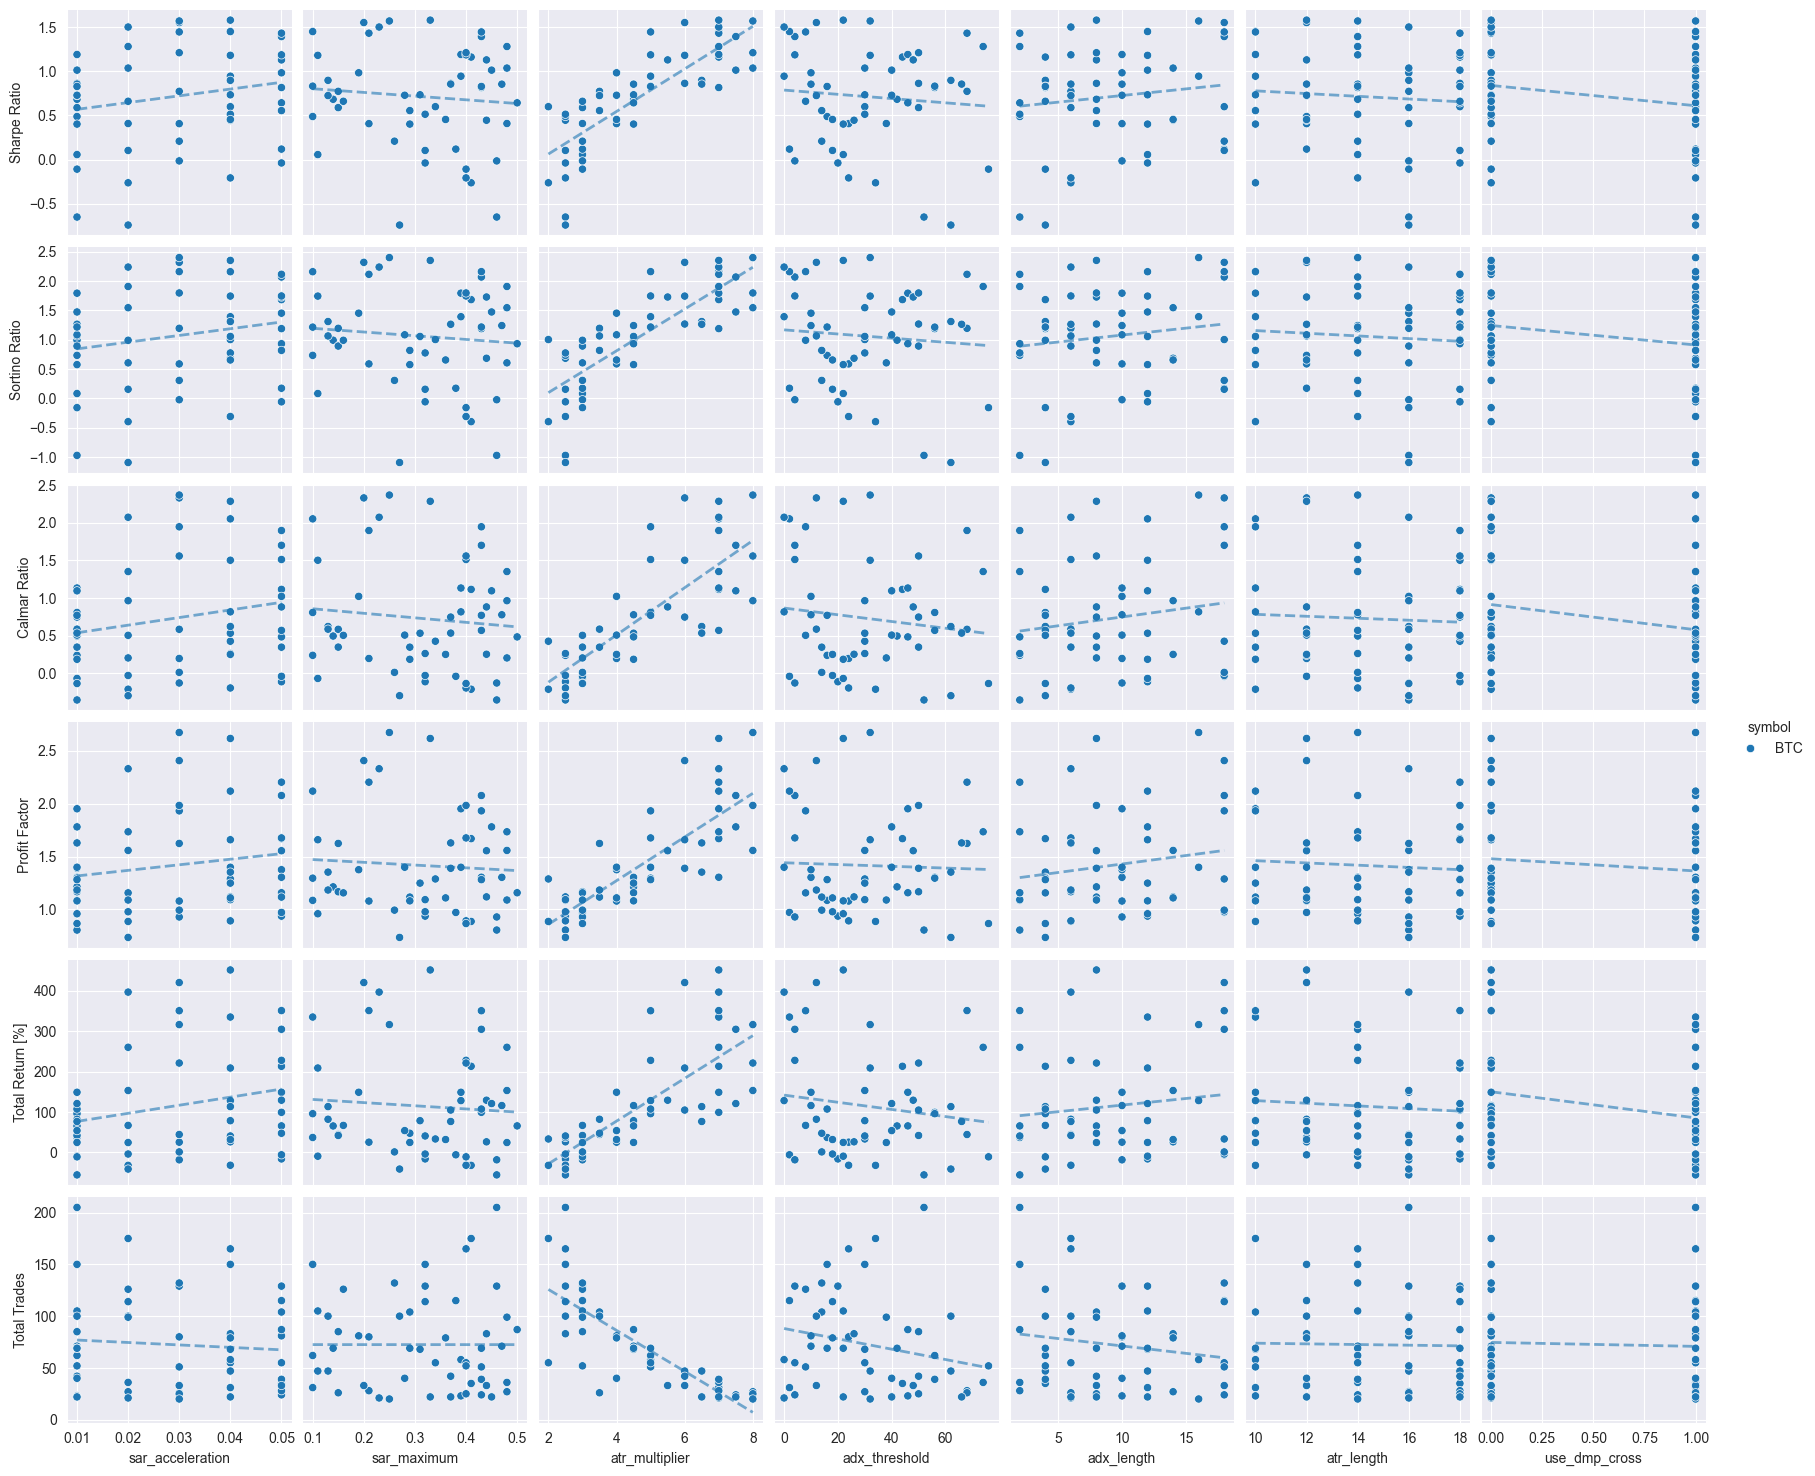

In [94]:

g = sns.pairplot(
    trials_summary,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g.axes[i, j]
        for sym, subdf in trials_summary.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )




In [109]:
print(tabulate(params.items(), headers=["Parameter", "Value"]))
entries, exits, stop_df, price_for_orders = calc_signals(close=close,
                                                         high=high,
                                                         low=low,
                                                         open_=open,
                                                         **params,
                                                         )
pf = vbt.Portfolio.from_signals(
    close=price_for_orders,
    entries=entries,
    exits=exits,
    init_cash=start_equity,
    fees=transaction_fee,
    slippage=0.0002
)

symbols_pf = [symbol_pf for _, symbol_pf in pf.wrapper.columns]

for symbol in symbols:
    symbol_pf_index = symbols_pf.index(symbol)
    one_pf = pf[pf.wrapper.columns[symbol_pf_index]]
    one_pf.plot(subplots=['trades', 'trade_pnl', 'cum_returns'], width=1200, title=f'{symbol}').show()

Parameter           Value
----------------  -------
sar_acceleration     0.04
sar_maximum          0.3
atr_multiplier       7.25
adx_threshold       24
adx_length          12.8
atr_length          15.2
use_dmp_cross        0


## Part2: Further exploration


Update defaults for:
- adx_threshold = 20 --> (8 -- 40)
- adx_length = 10 --> default 14 looks okay
- atr_length = 10 --> default 14 looks okay
- atr_multiplier = 3 --> (4 -- 6.5)
- sar_acceleration = 0.02 --> 0.03
- sar_maximum = 0.2 --> 0.3
- use_dmp_cross = True  --> False

In [96]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 2, 80, step=2)  #
    params['adx_length'] = trial.suggest_int("adx_length", 2, 18)
    params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.04, 0.04)  # default .02
    params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.3, 0.3)  # default .2
    params['use_dmp_cross'] = trial.suggest_categorical("use_dmp_cross", [False, False])

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 4.5, 6.5, step=0.5)
    params['atr_length'] = trial.suggest_int("atr_length", 12, 16)

    entries, exits, stop_df, price_for_orders = calc_signals(close=close,
                                                             high=high,
                                                             low=low,
                                                             open_=open,
                                                             **params,
                                                             )
    pf = vbt.Portfolio.from_signals(
        close=price_for_orders,
        entries=entries,
        exits=exits,
        init_cash=start_equity,
        fees=transaction_fee,
        slippage=0.0002
    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()
    low_trades = stats_df.loc["Total Trades"].min() < min_trades
    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    elif low_trades:
        raise optuna.exceptions.TrialPruned("Invalid objective (low trades).")
    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []

study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=n_trials)
trials_summary = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-11 23:31:15,622] A new study created in memory with name: no-name-be716c78-2429-4e45-a44a-59117e04127c
[I 2025-11-11 23:31:15,841] Trial 0 finished with value: 0.855594840383449 and parameters: {'adx_threshold': 58, 'adx_length': 4, 'sar_acceleration': 0.04, 'sar_maximum': 0.3, 'use_dmp_cross': False, 'atr_multiplier': 5.5, 'atr_length': 15}. Best is trial 0 with value: 0.855594840383449.
[I 2025-11-11 23:31:16,455] Trial 1 pruned. Invalid objective (NaN/Inf).
[I 2025-11-11 23:31:16,670] Trial 2 finished with value: 1.4389209095562745 and parameters: {'adx_threshold': 10, 'adx_length': 17, 'sar_acceleration': 0.04, 'sar_maximum': 0.3, 'use_dmp_cross': False, 'atr_multiplier': 5.5, 'atr_length': 13}. Best is trial 2 with value: 1.4389209095562745.
[I 2025-11-11 23:31:16,884] Trial 3 finished with value: 1.156325295912763 and parameters: {'adx_threshold': 6, 'adx_length': 7, 'sar_acceleration': 0.04, 'sar_maximum': 0.3, 'use_dmp_cross': False, 'atr_multiplier': 5.0, 'atr_lengt

In [97]:
trials = study.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start', 'datetime_complete', 'duration', 'state'], axis=1, inplace=True)
print(trials.head(10))

    number     value  adx_length  adx_threshold  atr_length  atr_multiplier  \
24      24  1.603627           2             18          14             6.5   
41      41  1.603627           2             20          14             6.5   
72      72  1.603627           2             18          14             6.5   
17      17  1.578299          11             16          13             6.5   
45      45  1.549493           5             24          14             6.5   
31      31  1.514140           9             56          15             6.0   
67      67  1.504987           7              2          14             6.0   
32      32  1.491545          12             22          12             6.5   
50      50  1.490493          18              6          12             6.5   
91      91  1.464583           8             28          14             6.5   

    sar_acceleration  sar_maximum  use_dmp_cross  
24              0.04          0.3          False  
41              0.04        

In [98]:
parameters = list(params.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]', 'Total Trades']

#convert bool to 0s and 1s
trials_summary['use_dmp_cross'] = trials_summary['use_dmp_cross'].astype(int)
top_10_pct = int(n_trials * 0.1)
print(f"\nTop 10% Trials Summary ({top_10_pct} Trials):")
cols = parameters + performance

top_runs = trials_summary.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol Average values:")
print(top_runs.groupby('symbol')[cols].mean())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())

# reset params
params = params_default.copy()
for param in params.keys():
    value = top_runs[param].mean()
    params[param] = value


Top 10% Trials Summary (10 Trials):

Per symbol Average values:
        sar_acceleration  sar_maximum  atr_multiplier  adx_threshold  \
symbol                                                                 
BTC                 0.04          0.3             6.4           21.0   

        adx_length  atr_length  use_dmp_cross  Sharpe Ratio  Sortino Ratio  \
symbol                                                                       
BTC            7.6        13.6            0.0      1.540442       2.311519   

        Calmar Ratio  Profit Factor  Total Return [%]  Total Trades  
symbol                                                               
BTC         2.179138        2.29674        399.765798          29.4  

Across all symbols:
       sar_acceleration   sar_maximum  atr_multiplier  adx_threshold  \
count      1.000000e+01  1.000000e+01       10.000000      10.000000   
mean       4.000000e-02  3.000000e-01        6.400000      21.000000   
std        7.314236e-18  5.851389e-1

In [99]:
fig3 = optuna.visualization.plot_param_importances(study)
show(fig3)

# fig4 = optuna.visualization.plot_slice(study2, params=best_params2.keys())
# show(fig4)


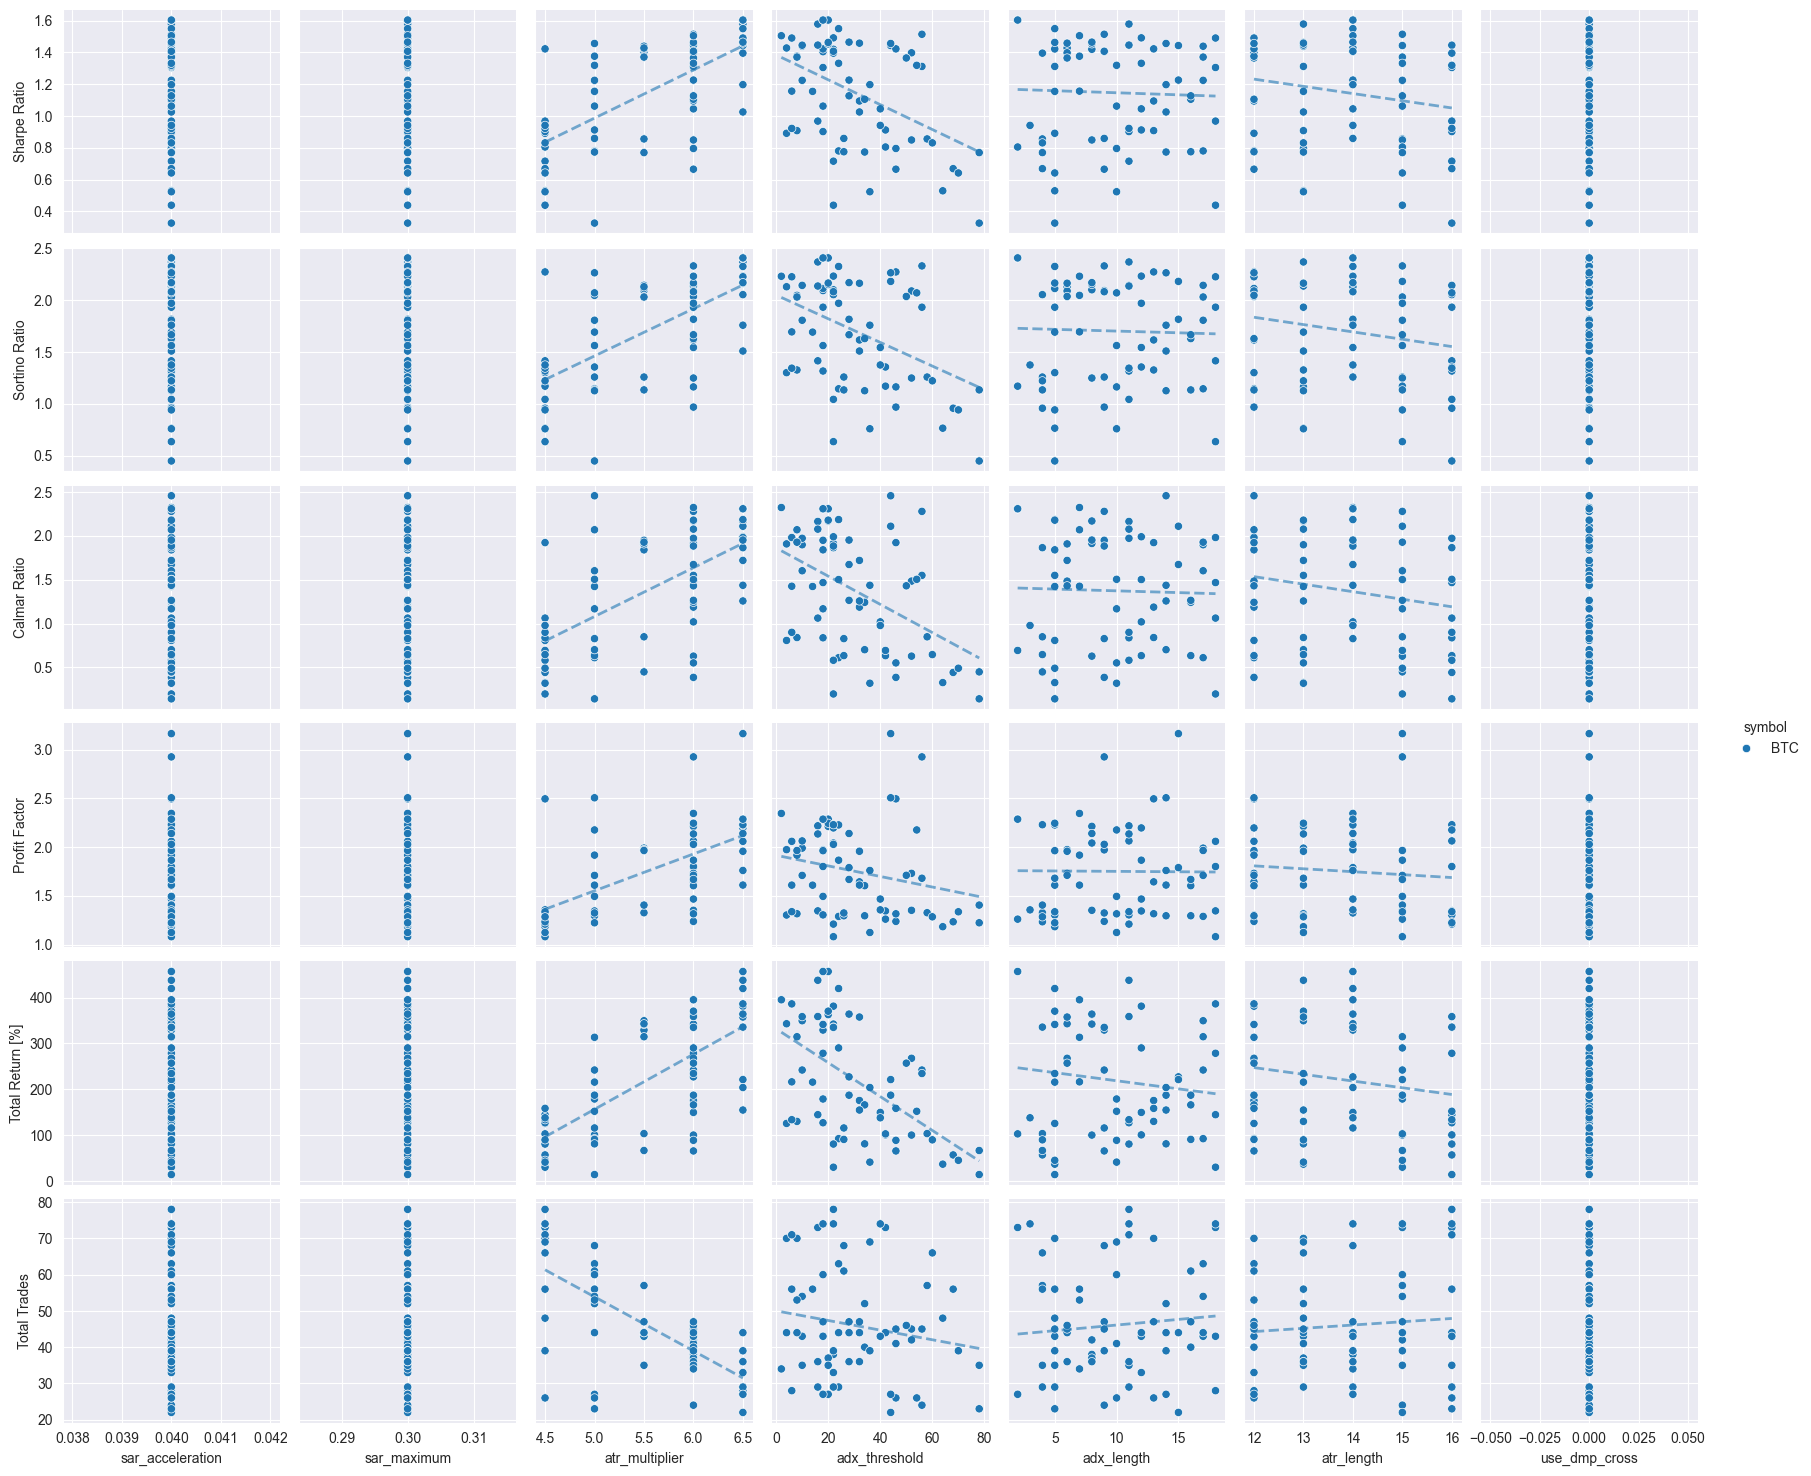

In [100]:

g = sns.pairplot(
    trials_summary,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g.axes[i, j]
        for sym, subdf in trials_summary.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )




In [108]:
print(tabulate(params.items(), headers=["Parameter", "Value"]))
entries, exits, stop_df, price_for_orders = calc_signals(close=close,
                                                         high=high,
                                                         low=low,
                                                         open_=open,
                                                         **params,
                                                         )
pf = vbt.Portfolio.from_signals(
    close=price_for_orders,
    entries=entries,
    exits=exits,
    init_cash=start_equity,
    fees=transaction_fee,
    slippage=0.0002
)

symbols_pf = [symbol_pf for _, symbol_pf in pf.wrapper.columns]

for symbol in symbols:
    symbol_pf_index = symbols_pf.index(symbol)
    one_pf = pf[pf.wrapper.columns[symbol_pf_index]]
    one_pf.plot(subplots=['trades', 'trade_pnl', 'cum_returns'], width=1200, title=f'{symbol}').show()

Parameter           Value
----------------  -------
sar_acceleration     0.04
sar_maximum          0.3
atr_multiplier       7.25
adx_threshold       24
adx_length          12.8
atr_length          15.2
use_dmp_cross        0


## Part 3: Extra, hmm but what does Optuna think is best?

I'll use the default search space and let Optuna explore the space and find the best parameters.

In [102]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 10, 46, step=2)  #
    params['adx_length'] = trial.suggest_int("adx_length", 10, max_lookback, step=2)
    # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.02, 1.5, step=0.01)
    # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.05, 1.7, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 1, 10, step=0.5)
    params['atr_length'] = trial.suggest_int("atr_length", 10, max_lookback, step=2)
    # params['use_high'] = trial.suggest_categorical("use_high", [True, False])

    entries, exits, stop_df, price_for_orders = calc_signals(close=close,
                                                             high=high,
                                                             low=low,
                                                             open_=open,
                                                             **params,
                                                             )
    pf = vbt.Portfolio.from_signals(
        close=price_for_orders,
        entries=entries,
        exits=exits,
        init_cash=start_equity,
        fees=transaction_fee,
        slippage=0.0002
    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()

    low_trades = stats_df.loc["Total Trades"].min() < min_trades
    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    elif low_trades:
        raise optuna.exceptions.TrialPruned("Invalid objective (low trades).")
    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []
params = params_default.copy()
study_opt = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_opt.optimize(objective, n_trials=n_trials)
trials_summary_opt = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-11 23:31:44,951] A new study created in memory with name: no-name-ad7a67c1-875b-4d74-b03e-829887ca8d54
[I 2025-11-11 23:31:45,176] Trial 0 finished with value: 1.7163411541123548 and parameters: {'adx_threshold': 24, 'adx_length': 18, 'atr_multiplier': 7.5, 'atr_length': 14}. Best is trial 0 with value: 1.7163411541123548.
[I 2025-11-11 23:31:45,373] Trial 1 finished with value: 0.15382161964892999 and parameters: {'adx_threshold': 14, 'adx_length': 10, 'atr_multiplier': 1.5, 'atr_length': 18}. Best is trial 0 with value: 1.7163411541123548.
[I 2025-11-11 23:31:45,573] Trial 2 finished with value: 0.47813036563916256 and parameters: {'adx_threshold': 32, 'adx_length': 16, 'atr_multiplier': 1.0, 'atr_length': 18}. Best is trial 0 with value: 1.7163411541123548.
[I 2025-11-11 23:31:45,776] Trial 3 finished with value: 0.11078677072107464 and parameters: {'adx_threshold': 40, 'adx_length': 12, 'atr_multiplier': 2.5, 'atr_length': 10}. Best is trial 0 with value: 1.7163411541123

In [103]:
trials = study_opt.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start', 'datetime_complete', 'duration', 'state'], axis=1, inplace=True)
print(tabulate(trials, headers='keys', tablefmt='github', showindex=False))



|   number |      value |   adx_length |   adx_threshold |   atr_length |   atr_multiplier |
|----------|------------|--------------|-----------------|--------------|------------------|
|        0 |   1.71634  |           18 |              24 |           14 |              7.5 |
|       98 |   1.61003  |           12 |              30 |           16 |              8   |
|       11 |   1.60565  |           14 |              26 |           10 |              7   |
|       60 |   1.58436  |           12 |              20 |           16 |              7   |
|       59 |   1.58436  |           12 |              20 |           16 |              7   |
|       64 |   1.58436  |           12 |              20 |           16 |              7   |
|       65 |   1.58436  |           12 |              20 |           16 |              7   |
|       61 |   1.58436  |           12 |              20 |           16 |              7   |
|       90 |   1.57389  |           12 |              30 |           1

In [104]:
parameters = list(params.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]']

print(f"\nTop 10% Trials Summary:")
cols = parameters + performance
top_10_pct = int(n_trials * 0.1)
top_runs = trials_summary_opt.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol:")
print(top_runs.groupby('symbol')[cols].describe())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())

# reset params
params = params_default.copy()
for param in params.keys():
    value = top_runs[param].mean()
    params[param] = value


Top 10% Trials Summary:

Per symbol:
       sar_acceleration                                                    \
                  count  mean           std   min   25%   50%   75%   max   
symbol                                                                      
BTC                10.0  0.04  7.314236e-18  0.04  0.04  0.04  0.04  0.04   

       sar_maximum       ... Profit Factor           Total Return [%]  \
             count mean  ...           75%       max            count   
symbol                   ...                                            
BTC           10.0  0.3  ...      2.607515  3.095565             10.0   

                                                                             \
              mean        std         min         25%        50%        75%   
symbol                                                                        
BTC     448.735187  32.648763  413.760131  443.045992  447.76181  447.76181   

                    
               max  
s

In [105]:
fig_opt = optuna.visualization.plot_param_importances(study_opt)
show(fig_opt)
fig_opt1 = optuna.visualization.plot_optimization_history(study_opt)
show(fig_opt1)
fig_opt2 = optuna.visualization.plot_slice(study_opt)
show(fig_opt2)





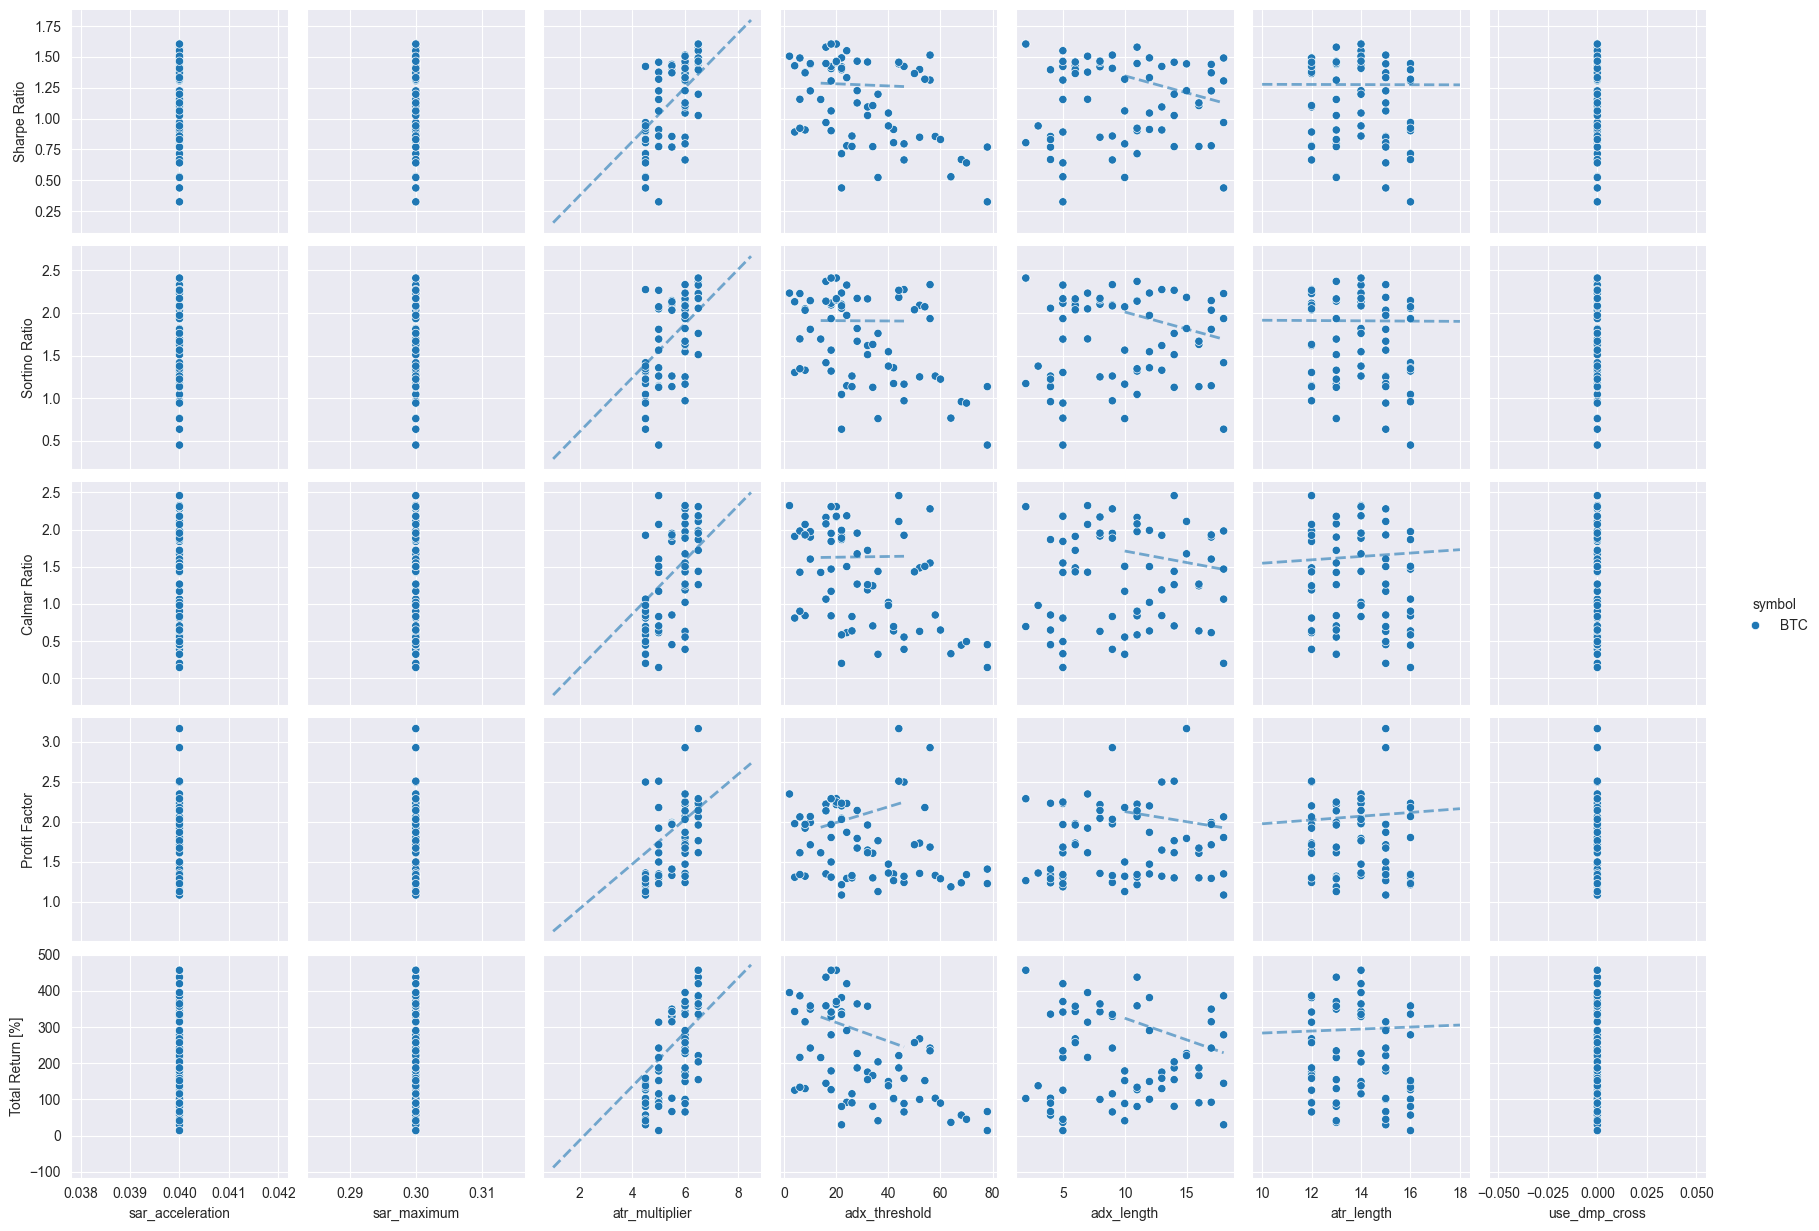

In [106]:
g_opt = sns.pairplot(
    trials_summary,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g_opt.axes[i, j]
        for sym, subdf in trials_summary_opt.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )
